In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

In [2]:
image = data.camera()
pixels = image.reshape(-1, 1)

In [3]:
#K-Means segmentation
kmeans = KMeans(
n_clusters=4,
random_state=42,
n_init=10
)

kmeans_labels = kmeans.fit_predict(pixels)

kmeans_segmented = kmeans.cluster_centers_[
kmeans_labels
].reshape(image.shape)

In [4]:
#GMM segmentation
gmm = GaussianMixture(
n_components=4,
random_state=42
)

gmm.fit(pixels)

gmm_labels = gmm.predict(pixels)

gmm_segmented = gmm.means_[
gmm_labels
].reshape(image.shape)

In [5]:
print("K-Means Cluster Sizes")
for i in range(4):
  print(f"Cluster {i}: {(kmeans_labels == i).sum()} pixels")

print("\nGMM Cluster Sizes")
for i in range(4):
  print(f"Cluster {i}: {(gmm_labels == i).sum()} pixels")

K-Means Cluster Sizes
Cluster 0: 83672 pixels
Cluster 1: 78702 pixels
Cluster 2: 78623 pixels
Cluster 3: 21147 pixels

GMM Cluster Sizes
Cluster 0: 75582 pixels
Cluster 1: 77935 pixels
Cluster 2: 21357 pixels
Cluster 3: 87270 pixels


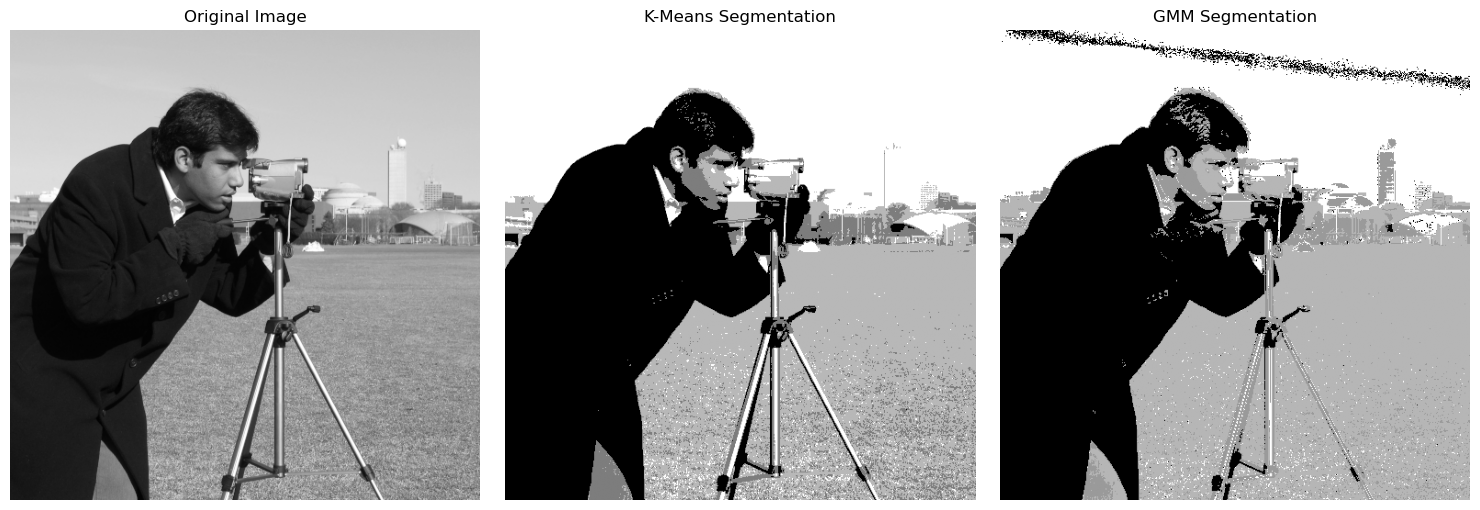

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(kmeans_segmented, cmap='gray')
ax[1].set_title("K-Means Segmentation")
ax[1].axis('off')

ax[2].imshow(gmm_segmented, cmap='gray')
ax[2].set_title("GMM Segmentation")
ax[2].axis('off')

plt.tight_layout()
plt.show()